#Actividad 2: Análisis de Asistencia y Resultados en Talleres de Capacitación

Consigna:

Cargá los conjuntos de datos.

Explorá cada DataFrame para familiarizarte con los datos.

Limpiá los datos.

Combiná los tres conjuntos de datos en un único DataFrame utilizando las claves apropiadas.

Realizá un análisis para calcular la asistencia promedio a los talleres y el puntaje promedio obtenido por los participantes, visualizando los resultados en gráficos.

In [23]:
import pandas as pd

df_talleres = pd.read_csv('https://drive.google.com/uc?id=1_gXuG8aG-c8y3LEEhPGZ07Cc6MUt8Ftu')
df_participantes = pd.read_csv('https://drive.google.com/uc?id=1etguzgVAHIBpFB1-qY8vXsjLQJxa6qpt')
df_resultados = pd.read_csv('https://drive.google.com/uc?id=11Te2oeBuumg-ZECxprQXizXAsgeMVn_5')

# Exploración

###Panorama general de los df

In [4]:
df_talleres.head()

,ID_Taller,Nombre_Taller
0,1,Introducción al Análisis de Datos con Excel
1,2,Visualización de Datos con Power BI
2,3,Estadística para Análisis de Datos
3,4,Python para Análisis de Datos
4,5,Análisis de Datos con R


In [5]:
df_participantes.head()

,ID_Participante,Nombre,Edad,Ciudad
0,408,Jackquelin Gonzalo,34,Avellaneda
1,203,Natassia Endon,35,San Fernando
2,55,Daloris Fruser,40,Berisso
3,296,Addy Lorant,29,Tigre
4,427,Laurens Gladdor,33,Punta Lara


In [6]:
df_resultados.head()

,ID_Taller,ID_Participante,Asistió,Puntaje
0,5,35,False,4.36
1,9,989,True,3.48
2,6,636,True,8.15
3,2,742,True,6.85
4,10,170,True,4.51


###Información de los df

In [7]:
df_talleres.info()
# colum: 'Nombre_Taller' convertir a string

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID_Taller      10 non-null     int64 
 1   Nombre_Taller  10 non-null     object
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


In [8]:
df_participantes.info()
# colum: 'Nombre', 'Ciudad' convertir a string

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_Participante  1014 non-null   int64 
 1   Nombre           1014 non-null   object
 2   Edad             1014 non-null   int64 
 3   Ciudad           1014 non-null   object
dtypes: int64(2), object(2)
memory usage: 31.8+ KB


In [9]:
df_resultados.info()
# 4 registros NAN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Taller        1000 non-null   int64  
 1   ID_Participante  1000 non-null   int64  
 2   Asistió          1000 non-null   bool   
 3   Puntaje          996 non-null    float64
dtypes: bool(1), float64(1), int64(2)
memory usage: 24.5 KB


###Datos estadísiticos

In [10]:
df_participantes['Edad'].describe().round(2)

,Edad
count,1014.00
mean,33.57
std,4.81
min,19.00
25%,30.00
50%,34.00
75%,37.00
max,48.00


In [11]:
df_resultados['Puntaje'].describe().round(2)

,Puntaje
count,996.00
mean,5.97
std,1.48
min,0.83
25%,4.95
50%,5.98
75%,6.94
max,10.55


### Limpieza

###Valores nulos

In [12]:
df_resultados.isnull().sum()

,0
ID_Taller,0
ID_Participante,0
Asistió,0
Puntaje,4


### Completar con el promedio

In [13]:
df_resultados['Puntaje'] = df_resultados['Puntaje'].fillna(df_resultados['Puntaje'].mean())

### Duplicados

In [14]:
print("Duplicados: ", df_participantes.duplicated().sum(), "de:", len(df_participantes),"\n",
      "representa el: ", round(df_participantes.duplicated().sum()/len(df_participantes)*100,2),"%")
# Bajo porcentaje de duplicado en df_participantes,
# además los datos refieren a personas por lo que resulta
# relevante eliminar los duplicados para un mejor analísis.
print("Duplicados: ", df_resultados.duplicated().sum(), "de:", len(df_resultados),"\n")

Duplicados:  14 de: 1014 
 representa el:  1.38 %
Duplicados:  0 de: 1000 



#### Ver participanetes repetidos

In [15]:
participantes_duplicados = df_participantes[df_participantes.duplicated()]
participantes_duplicados

,ID_Participante,Nombre,Edad,Ciudad
1000,865,Beret Saura,33,Pilar
1001,729,Humfrid Nys,36,Tres de Febrero
1002,785,Min Viger,30,Avellaneda
1003,717,Nalani Helm,31,San Isidro
1004,830,Bill Penddreth,28,Quilmes
1005,480,Mathe Babington,30,La Matanza
1006,548,Veronike Davies,30,Escobar
1007,855,Marni Blowne,31,Quilmes
1008,116,Sunny Growcott,36,Castro Barros
1009,131,Morganica Spradbery,34,La Plata


#### Eliminar Duplicados

In [16]:
df_participantes = df_participantes.drop_duplicates()

## Combinar df

In [17]:
result_participantes = pd.merge(left=df_resultados, right=df_participantes, on='ID_Participante', how='outer')
result_part_talleres = pd.merge(left=result_participantes, right=df_talleres, on='ID_Taller', how='outer', indicator=True)

##Realizá un análisis para calcular la asistencia promedio a los talleres y el puntaje promedio obtenido por los participantes, visualizando los resultados en gráficos.

### asistencia promedio a los talleres

In [18]:
promedio_asistencia_por_taller = result_part_talleres.groupby('Nombre_Taller')['Asistió'].mean().round(2)
promedio_asistencia_por_taller

,Asistió
Nombre_Taller,
Análisis Predictivo y Modelado Estadístico,0.93
Análisis de Datos con R,0.91
Análisis de Datos en SQL,0.89
Big Data y Procesamiento de Datos,0.93
Data Science para No Científicos,0.96
Estadística para Análisis de Datos,0.90
Introducción al Análisis de Datos con Excel,0.93
Minería de Datos y Machine Learning,0.94
Python para Análisis de Datos,0.92


###puntaje promedio obtenido por los participantes

In [19]:
puntaje_promedio_por_participante = result_part_talleres.groupby('Nombre')['Puntaje'].mean().round(2).sort_values(ascending=False)
puntaje_promedio_por_participante

,Puntaje
Nombre,
Trumaine Scandrett,10.55
Phyllida Riccione,9.90
Gustave Brader,9.87
Julio Radenhurst,9.85
Araldo Belford,9.82
...,...
Gaby Blois,2.13
Lion Penwright,1.89
Sascha Langton,1.77


### Gráficos

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

#### gráfico de asistencia promedio a los talleres

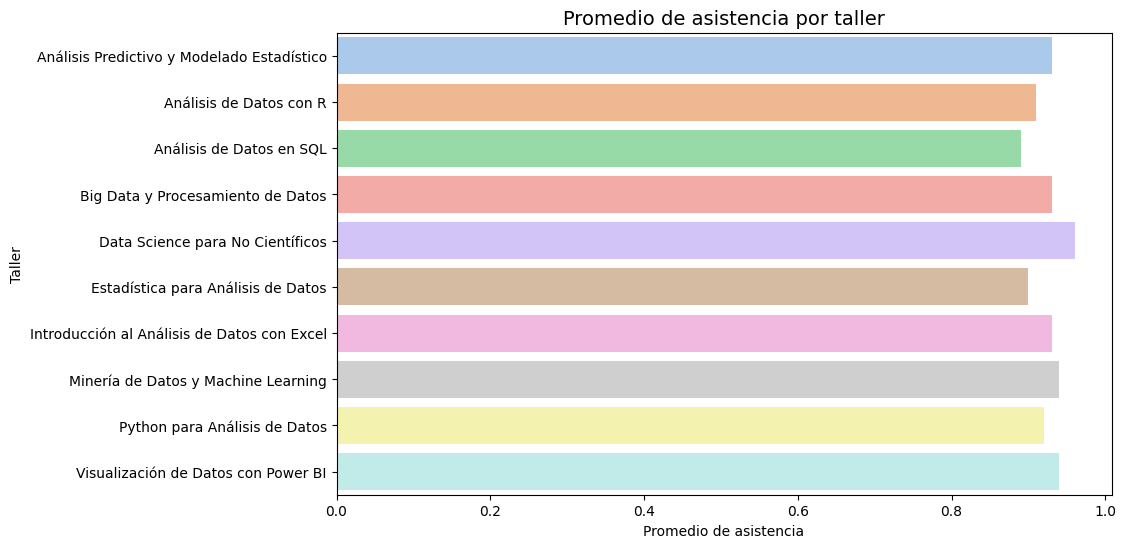

In [21]:
# contenedor del gráfico
plt.figure(figsize=(10, 6))

# gráfico de barras con seaborn
sns.barplot(
    x=promedio_asistencia_por_taller.values,
    y=promedio_asistencia_por_taller.index,
    palette='pastel',
    hue=promedio_asistencia_por_taller.index,
    legend=False,
    )

# título y etiquetas para los ejes
plt.title("Promedio de asistencia por taller", fontsize=14)
plt.xlabel("Promedio de asistencia")
plt.ylabel("Taller")

# vista del gráfico
plt.show()

### Gráfico promedio de notas por alumno

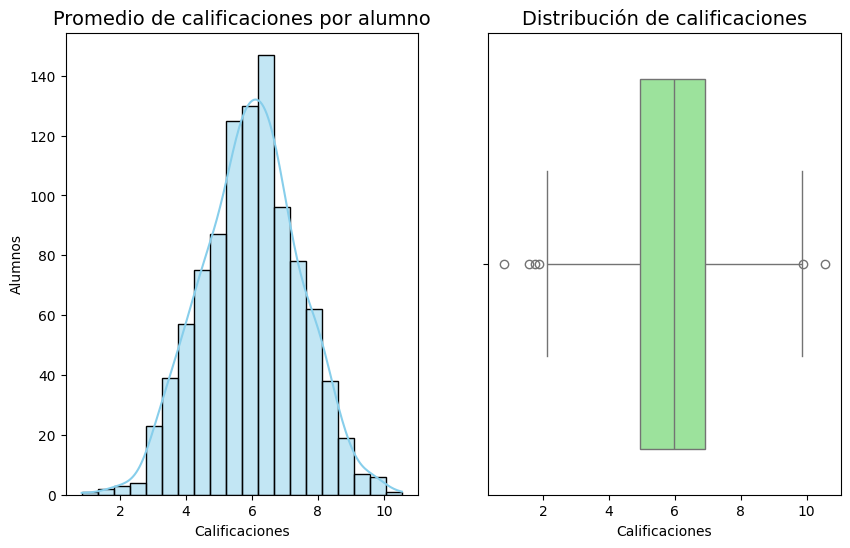

In [25]:
# contenedor del gráfico
plt.figure(figsize=(10, 6))

# gráfico de barras con seaborn
plt.subplot(1, 2, 1)
sns.histplot(
    puntaje_promedio_por_participante.values,
    bins=20,
    kde=True,
    color='skyblue'
    )

# título y etiquetas para los ejes
plt.title("Promedio de calificaciones por alumno", fontsize=14)
plt.xlabel("Calificaciones")
plt.ylabel("Alumnos")

plt.subplot(1, 2, 2)
sns.boxplot(
    x=puntaje_promedio_por_participante.values,
    color='lightgreen'
    )
plt.xlabel("Calificaciones")
plt.title("Distribución de calificaciones", fontsize=14)

# vista del gráfico
plt.show()